https://hf-mirror.com/docs/peft/task_guides/lora_based_methods?loras=LoRA

In [1]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

In [2]:
from datasets import load_dataset

ds = load_dataset("food101")
ds

d:\miniconda3\envs\PyTorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 75750
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 25250
    })
})

In [3]:
ds['train']

Dataset({
    features: ['image', 'label'],
    num_rows: 75750
})

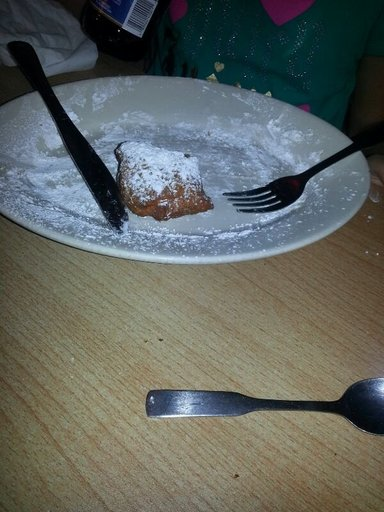

In [4]:
ds['train'][0]['image']

In [5]:
labels = ds["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

label2id, id2label

({'apple_pie': 0,
  'baby_back_ribs': 1,
  'baklava': 2,
  'beef_carpaccio': 3,
  'beef_tartare': 4,
  'beet_salad': 5,
  'beignets': 6,
  'bibimbap': 7,
  'bread_pudding': 8,
  'breakfast_burrito': 9,
  'bruschetta': 10,
  'caesar_salad': 11,
  'cannoli': 12,
  'caprese_salad': 13,
  'carrot_cake': 14,
  'ceviche': 15,
  'cheesecake': 16,
  'cheese_plate': 17,
  'chicken_curry': 18,
  'chicken_quesadilla': 19,
  'chicken_wings': 20,
  'chocolate_cake': 21,
  'chocolate_mousse': 22,
  'churros': 23,
  'clam_chowder': 24,
  'club_sandwich': 25,
  'crab_cakes': 26,
  'creme_brulee': 27,
  'croque_madame': 28,
  'cup_cakes': 29,
  'deviled_eggs': 30,
  'donuts': 31,
  'dumplings': 32,
  'edamame': 33,
  'eggs_benedict': 34,
  'escargots': 35,
  'falafel': 36,
  'filet_mignon': 37,
  'fish_and_chips': 38,
  'foie_gras': 39,
  'french_fries': 40,
  'french_onion_soup': 41,
  'french_toast': 42,
  'fried_calamari': 43,
  'fried_rice': 44,
  'frozen_yogurt': 45,
  'garlic_bread': 46,
  'gnocc

In [6]:
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [7]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
train_transforms = Compose(
    [
        RandomResizedCrop(image_processor.size["height"]),
        RandomHorizontalFlip(),
        ToTensor(),
        normalize,
    ]
)

val_transforms = Compose(
    [
        Resize(image_processor.size["height"]),
        CenterCrop(image_processor.size["height"]),
        ToTensor(),
        normalize,
    ]
)

def preprocess_train(example_batch):
    example_batch["pixel_values"] = [train_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

def preprocess_val(example_batch):
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

In [8]:
train_ds = ds["train"]
val_ds = ds["validation"]

train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

In [9]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [10]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# LoRA
# from peft import LoraConfig, get_peft_model

# config = LoraConfig(
#     r=16,
#     lora_alpha=16,
#     target_modules=["query", "value"],
#     lora_dropout=0.1,
#     bias="none",
#     modules_to_save=["classifier"],
# )
# model = get_peft_model(model, config)
# model.print_trainable_parameters()

# LoHa
# from peft import LoHaConfig, get_peft_model

# config = LoHaConfig(
#     r=16,
#     alpha=16,
#     target_modules=["query", "value"],
#     module_dropout=0.1,
#     modules_to_save=["classifier"],
# )
# model = get_peft_model(model, config)
# model.print_trainable_parameters()

# LoKr
from peft import LoKrConfig, get_peft_model

config = LoKrConfig(
    r=16,
    alpha=16,
    target_modules=["query", "value"],
    module_dropout=0.1,
    modules_to_save=["classifier"],
)
model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 116,069 || all params: 85,992,394 || trainable%: 0.1350


In [12]:
from transformers import TrainingArguments, Trainer

peft_model_id = f"./google/vit-base-patch16-224-in21k-lora"
batch_size = 96

args = TrainingArguments(
    peft_model_id,
    remove_unused_columns=False,
    eval_strategy="steps",
    learning_rate=5e-3,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=batch_size,
    fp16=True,
    num_train_epochs=5,
    logging_steps=20,
    load_best_model_at_end=True,
    label_names=["labels"]
)

In [13]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_ds.select(range(10000)),
    eval_dataset=val_ds.select(range(1000)),
    processing_class=image_processor,
    data_collator=collate_fn,
)

In [14]:
trainer.train()

Step,Training Loss,Validation Loss
20,1.720700,0.249809
40,0.328900,0.127978
60,0.268500,0.092781
80,0.250900,0.098642
100,0.246200,0.088996
120,0.217600,0.086274


TrainOutput(global_step=135, training_loss=0.47277262475755477, metrics={'train_runtime': 384.9621, 'train_samples_per_second': 129.883, 'train_steps_per_second': 0.351, 'total_flos': 3.8832789252096e+18, 'train_loss': 0.47277262475755477, 'epoch': 5.0})

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


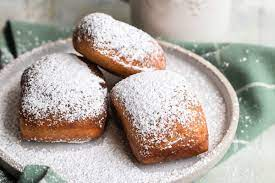

In [15]:
from peft import PeftConfig, PeftModel
from transformers import AutoImageProcessor
from PIL import Image
import requests

config = PeftConfig.from_pretrained("./google/vit-base-patch16-224-in21k-lora/checkpoint-135")
model = AutoModelForImageClassification.from_pretrained(
    config.base_model_name_or_path,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)
model = PeftModel.from_pretrained(model, "./google/vit-base-patch16-224-in21k-lora/checkpoint-135")

image = Image.open('./beignets.jpeg')
image

In [16]:
encoding = image_processor(image.convert("RGB"), return_tensors="pt")

In [17]:
with torch.no_grad():
    outputs = model(**encoding)
    logits = outputs.logits

predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])

Predicted class: beignets
